# 1-Import libarires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2-Load data

In [11]:
plt.rcParams["figure.figsize"] = (10,6)
df = pd.read_csv("/content/raw/cat_breeds_dirty.csv", sep=';')
df.head()

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.25,3.0,female,False,19.0,2.0,white,solid,blue,FALSE,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.33,4.0,male,False,19.0,2.5,white,solid,blue,FALSE,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.50,NaN,NaN,False,20.0,2.8,what does it mean dominant?,solid,green,I never allow my kitty outside!!!!!,wet,41.0,11.0,France,44.837789,-0.579180
3,Ankora,0.50,NaN,NaN,False,21.0,3.0,white,dirty,blue,FALSE,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.50,NaN,NaN,NaN,21.0,3.0,red/cream,tabby,green,FALSE,wet,51.0,10.0,france,48.864716,2.349014


# 3-EDA

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    991 non-null    object 
 1   Age_in_years             1072 non-null   float64
 2   Age_in_months            1066 non-null   float64
 3   Gender                   1036 non-null   object 
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1077 non-null   float64
 6   Weight                   1077 non-null   float64
 7   Fur_colour_dominant      1090 non-null   object 
 8   Fur_pattern              1055 non-null   object 
 9   Eye_colour               1064 non-null   object 
 10  Allowed_outdoor          1060 non-null   object 
 11  Preferred_food           1082 non-null   object 
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14  Country                 

In [16]:
df.columns
df.nunique().sort_values()

,0
Gender,2
Neutered_or_spayed,2
Preferred_food,3
Allowed_outdoor,4
Eye_colour,6
Fur_pattern,7
Fur_colour_dominant,7
Country,11
Breed,12
Sleep_time_hours,17


# • Dataset contains missing values in several columns
# • Presence of outliers in numerical features
# • Some categorical columns have high cardinality
# • Potential data quality issues (dirty data)


In [17]:
df.isnull().sum().sort_values(ascending=False)

,0
Breed,112
Country,75
Gender,67
Latitude,61
Longitude,61
Neutered_or_spayed,53
Fur_pattern,48
Allowed_outdoor,43
Sleep_time_hours,41
Eye_colour,39


In [20]:
df.duplicated().sum()

np.int64(32)

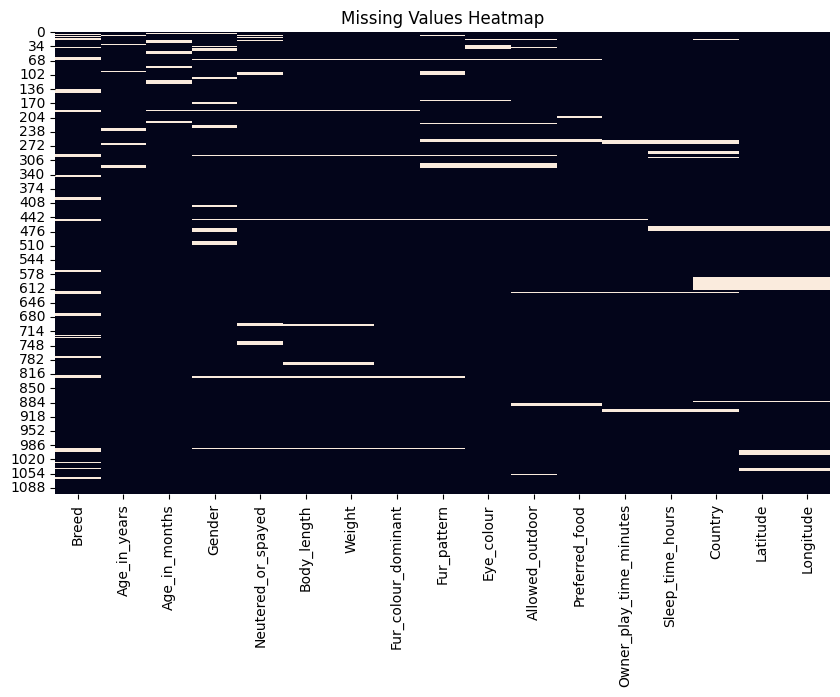

In [29]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [21]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age_in_years,1072.0,4.460752,3.262166,-7.666667,2.33000,4.750000,6.920000,11.250000
Age_in_months,1066.0,53.778612,39.355581,-92.000000,28.00000,57.000000,84.000000,135.000000
Body_length,1077.0,43.903435,16.240466,10.000000,35.00000,41.000000,51.000000,102.000000
Weight,1077.0,5.740901,9.853438,0.500000,3.90000,5.000000,7.000000,320.000000
Owner_play_time_minutes,1082.0,23.176525,10.815298,0.000000,15.00000,23.000000,31.000000,60.000000
Sleep_time_hours,1062.0,15.898305,2.656775,8.000000,14.00000,16.000000,18.000000,32.000000
Latitude,1042.0,44.550898,4.931844,37.774930,40.71427,43.296482,48.864716,53.800755
Longitude,1042.0,-59.517623,46.259368,-123.116226,-77.03637,-74.005970,-1.890401,13.404954


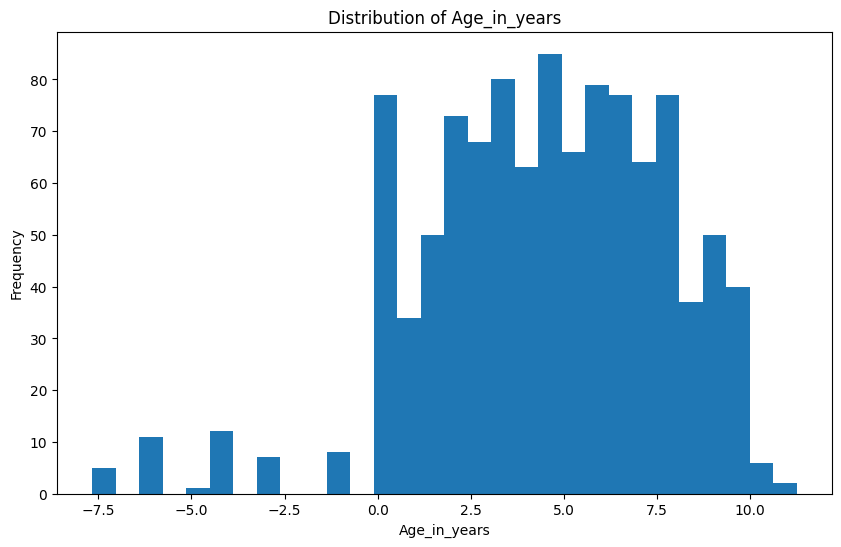

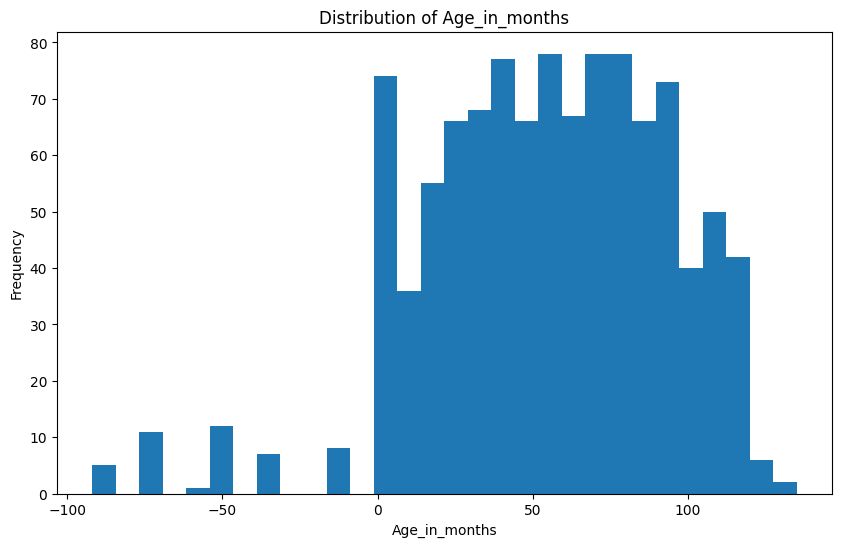

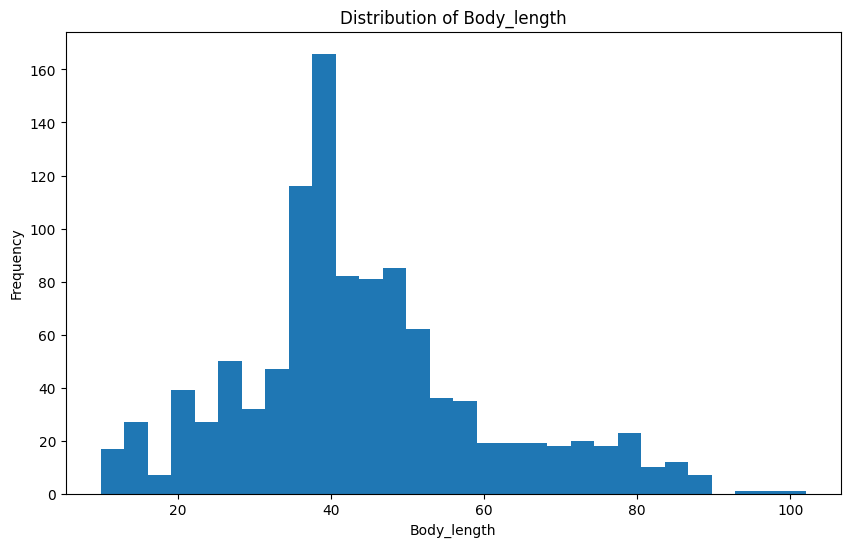

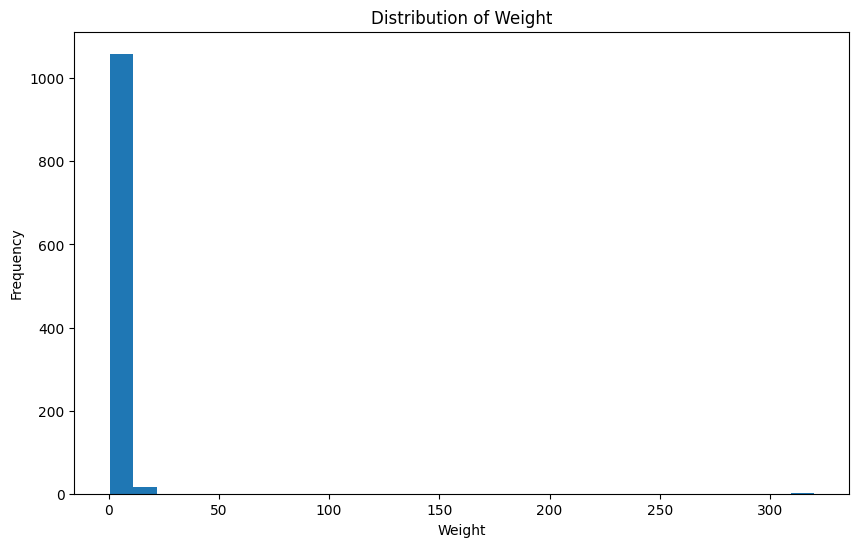

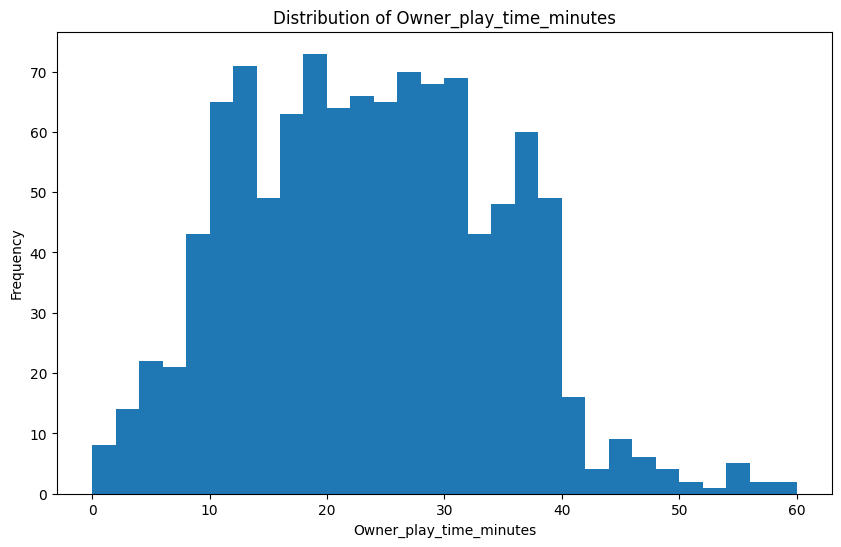

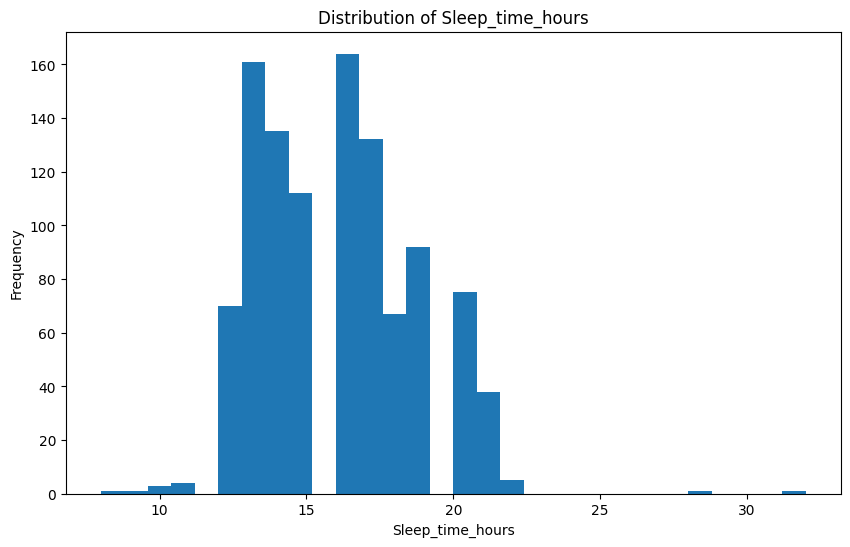

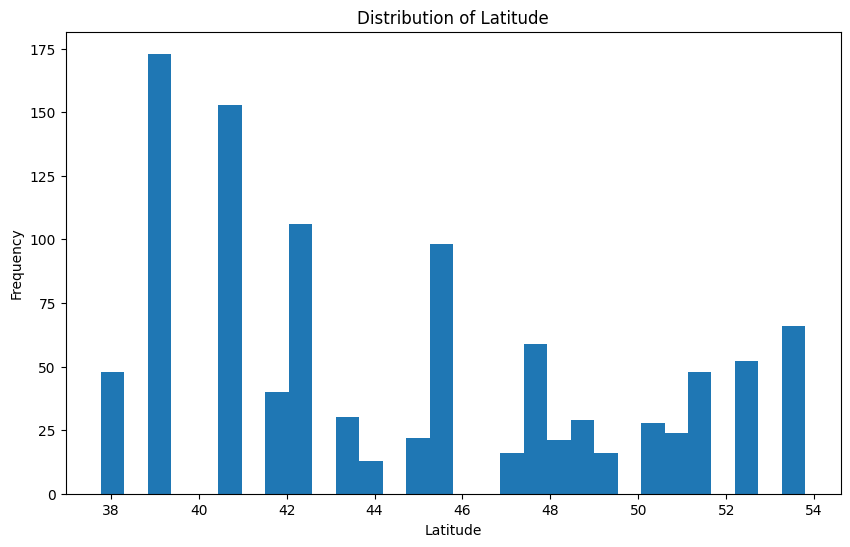

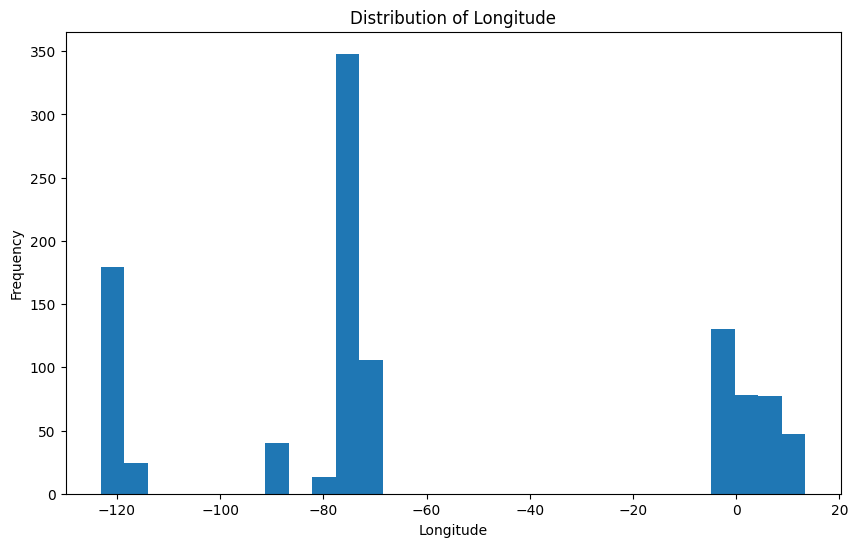

In [22]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [23]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts().head(10))


 Breed
Breed
Ragdoll       374
Maine coon    268
Angora        258
My coon        27
Ankora         19
Angorra        11
wrack doll      9
ragdoll         7
Maine loon      7
rack doll       6
Name: count, dtype: int64

 Gender
Gender
male      522
female    514
Name: count, dtype: int64

 Neutered_or_spayed
Neutered_or_spayed
True     613
False    437
Name: count, dtype: int64

 Fur_colour_dominant
Fur_colour_dominant
seal                           292
white                          281
black                          216
red/cream                      148
brown/chocolate                147
lilac                            5
what does it mean dominant?      1
Name: count, dtype: int64

 Fur_pattern
Fur_pattern
solid         452
colorpoint    337
tabby         112
bicolor        96
tortie         39
mitted         10
dirty           9
Name: count, dtype: int64

 Eye_colour
Eye_colour
blue                        541
yellow                      246
green                       165
amber  

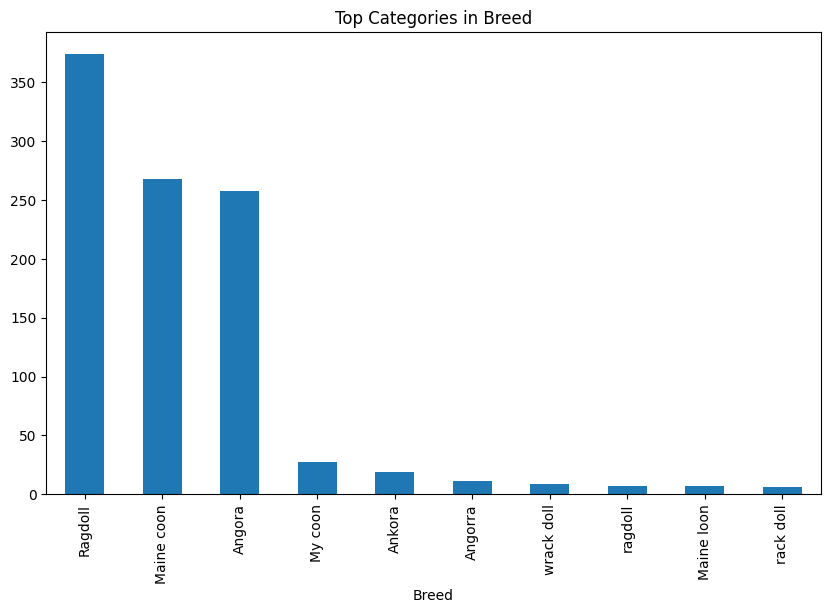

In [24]:
df[categorical_cols[0]].value_counts().head(10).plot(kind="bar")
plt.title(f"Top Categories in {categorical_cols[0]}")
plt.show()


# 4-Box plots

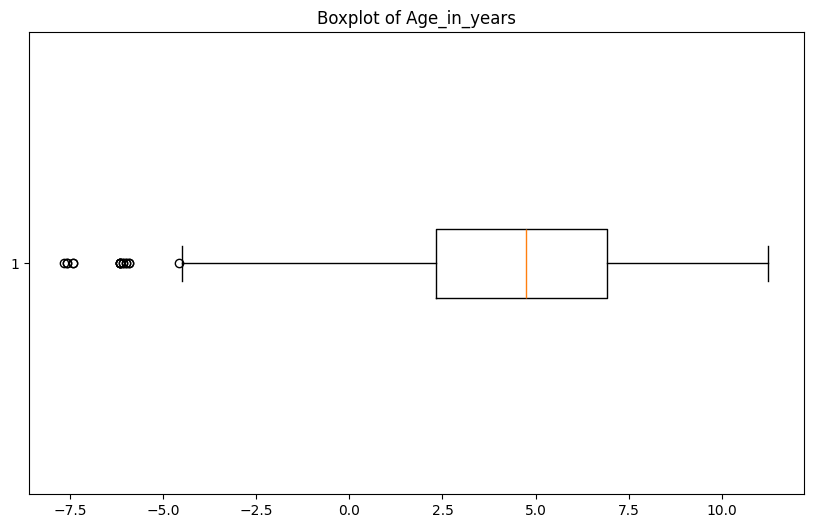

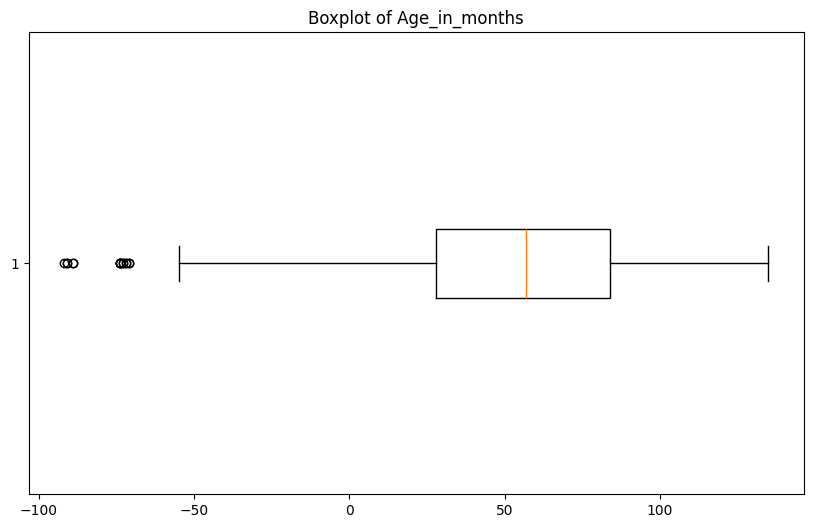

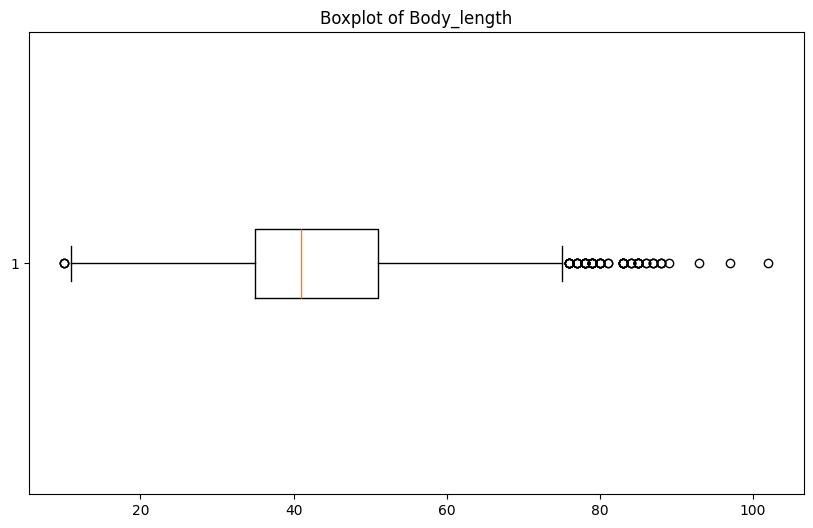

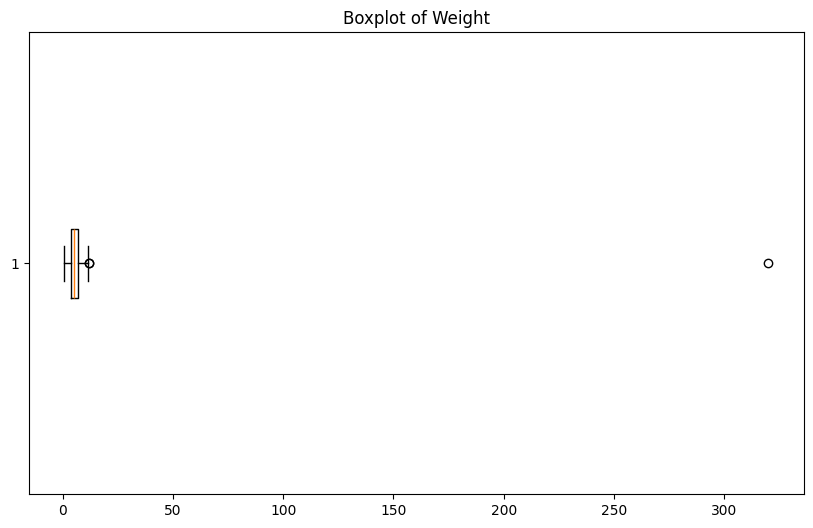

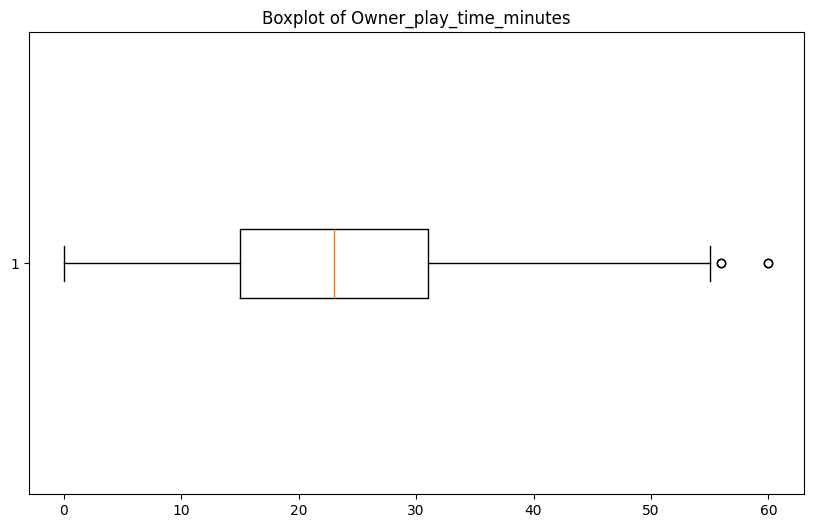

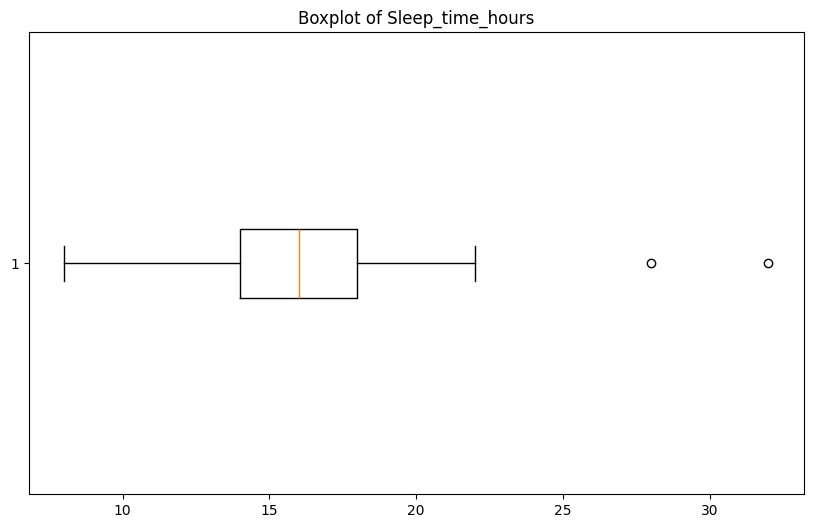

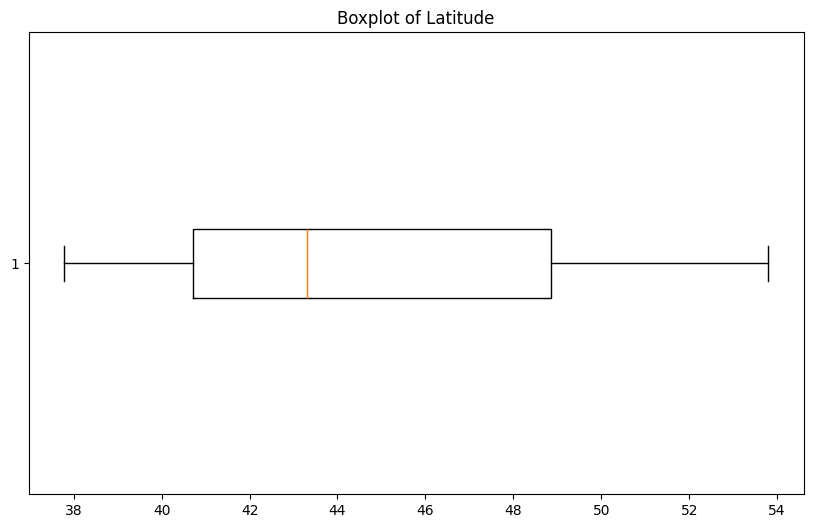

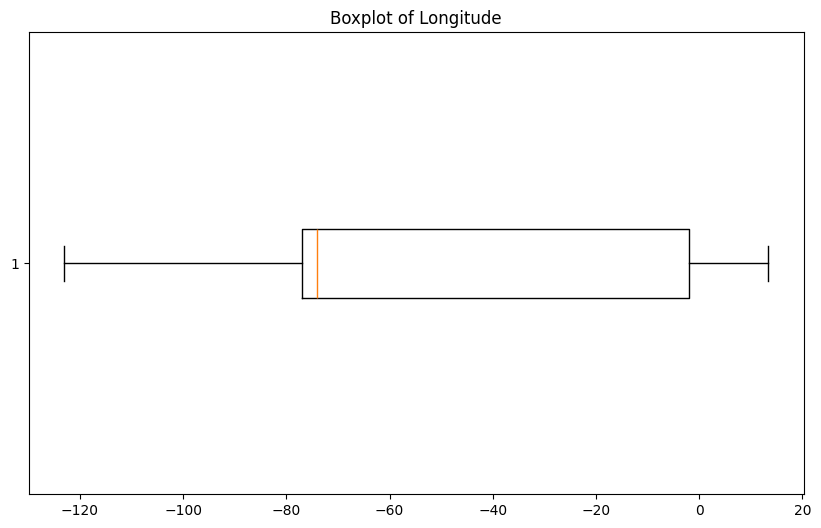

In [25]:
for col in numeric_cols:
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()


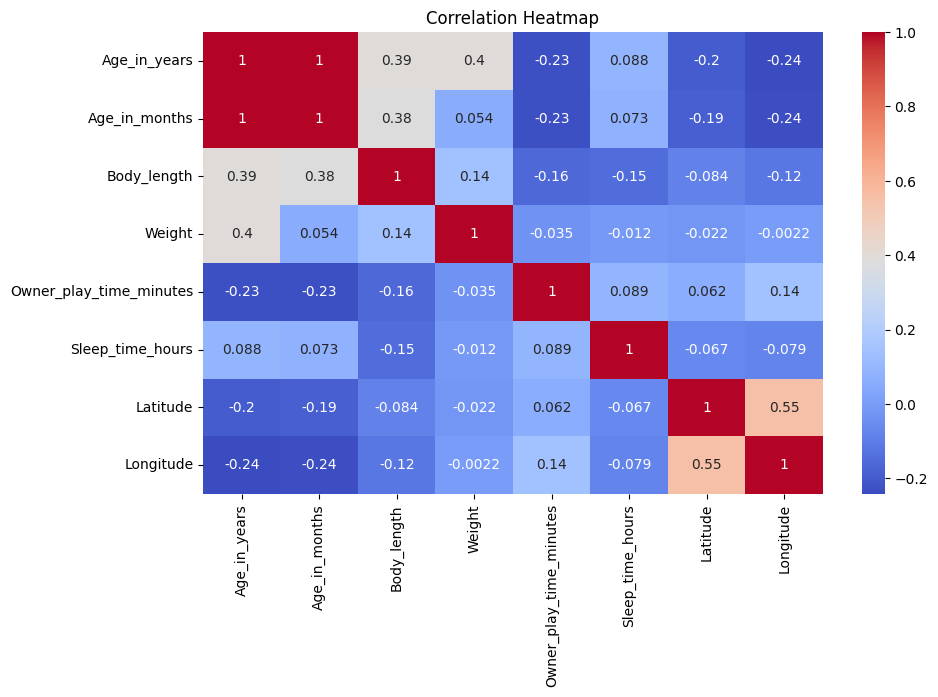

In [26]:
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
